In [53]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
import warnings
warnings.filterwarnings('ignore')
from collections import Counter

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

print('All libraries imported successfully!')

All libraries imported successfully!


In [35]:
df = pd.read_csv('../../data/raw/youtoxic_english_1000.csv')

print(f'Shape of dataset: {df.shape}')
print(f'Columns of dataset: {df.columns.tolist()}')
df.head(3)

Shape of dataset: (1000, 15)
Columns of dataset: ['CommentId', 'VideoId', 'Text', 'IsToxic', 'IsAbusive', 'IsThreat', 'IsProvocative', 'IsObscene', 'IsHatespeech', 'IsRacist', 'IsNationalist', 'IsSexist', 'IsHomophobic', 'IsReligiousHate', 'IsRadicalism']


,CommentId,VideoId,Text,IsToxic,IsAbusive,IsThreat,IsProvocative,IsObscene,IsHatespeech,IsRacist,IsNationalist,IsSexist,IsHomophobic,IsReligiousHate,IsRadicalism
0,Ugg2KwwX0V8-aXgCoAEC,04kJtp6pVXI,If only people would just take a step back and...,False,False,False,False,False,False,False,False,False,False,False,False
1,Ugg2s5AzSPioEXgCoAEC,04kJtp6pVXI,Law enforcement is not trained to shoot to app...,True,True,False,False,False,False,False,False,False,False,False,False
2,Ugg3dWTOxryFfHgCoAEC,04kJtp6pVXI,\nDont you reckon them 'black lives matter' ba...,True,True,False,False,True,False,False,False,False,False,False,False


                 count  keep                 reason
IsToxic            462  keep  More than 50 examples
IsAbusive          353  keep  More than 50 examples
IsThreat            21  drop  Less than 50 examples
IsProvocative      161  keep  More than 50 examples
IsObscene          100  keep  More than 50 examples
IsHatespeech       138  keep  More than 50 examples
IsRacist           125  keep  More than 50 examples
IsNationalist        8  drop  Less than 50 examples
IsSexist             1  drop  Less than 50 examples
IsHomophobic         0  drop  Less than 50 examples
IsReligiousHate     12  drop  Less than 50 examples
IsRadicalism         0  drop  Less than 50 examples


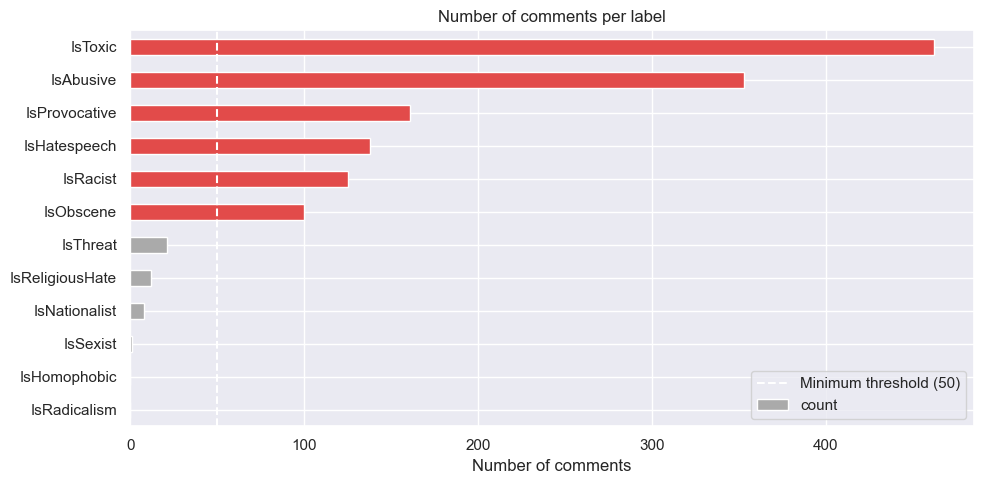

Final dataset shape: (1000, 2)


In [ ]:
label_counts = {col: (df[col] == True).sum() for col in df.columns[3:]}
label_df = pd.DataFrame.from_dict(label_counts, orient="index", columns=['count'])
label_df['count'] = label_df['count'].astype(int)
label_df['keep'] = label_df["count"].apply(lambda x: 'keep' if x > 50 else 'drop')
label_df['reason'] = label_df['keep'].map({
    'keep': 'More than 50 examples', 
    'drop': 'Less than 50 examples'
})

print(label_df)

label_df['count'].sort_values().plot(
    kind='barh',
    color=['#E24B4A' if k == 'keep' else '#aaaaaa' for k in label_df.sort_values('count')['keep']],
    figsize=(10, 5)
)
plt.axvline(x=50, color='white', linestyle='--', label='Minimum threshold (50)')
plt.title('Number of comments per label')
plt.xlabel('Number of comments')
plt.legend()
plt.tight_layout()
plt.show()

df = df[['Text', 'IsToxic']]
print(f'Final dataset shape: {df.shape}')

In [37]:
print(df.isnull().sum())

print(df.duplicated().sum())

dupes = df[df['Text'].str.lower().duplicated(keep=False)]
print(dupes.sort_values('Text'))

df['text_lower'] = df['Text'].str.lower().str.strip()
df = df.drop_duplicates(subset='text_lower').drop(columns='text_lower')
df = df.reset_index(drop=True)

print(f'Dataset after cleaning: {df.shape}')

Text       0
IsToxic    0
dtype: int64
3
              Text  IsToxic
592  RUN THEM OVER     True
699  RUN THEM OVER     True
578  Run them over     True
642  run them over     True
657  run them over     True
677  run them over     True
Dataset after cleaning: (995, 2)


=== Class Distribution ===
Not Toxic (0): 538 (54.1%)
Toxic     (1): 457 (45.9%)
Ratio: 1.18x

Conclusion: reasonably balanced — no SMOTE needed
Action: use class_weight=balanced in all models as preventive measure


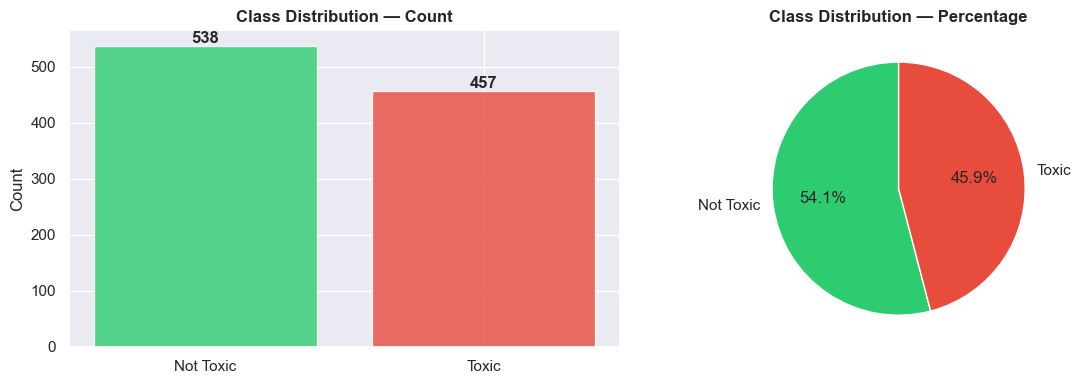

In [41]:
class_counts = df['IsToxic'].value_counts()
class_pct = df['IsToxic'].value_counts(normalize=True) * 100

print('=== Class Distribution ===')
print(f'Not Toxic (0): {class_counts[False]} ({class_pct[False]:.1f}%)')
print(f'Toxic     (1): {class_counts[True]} ({class_pct[True]:.1f}%)')
print(f'Ratio: {class_counts[False]/class_counts[True]:.2f}x')
print('\nConclusion: reasonably balanced — no SMOTE needed')
print('Action: use class_weight=balanced in all models as preventive measure')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Not Toxic', 'Toxic'], class_counts.values,
            color=['#2ecc71', '#e74c3c'], alpha=0.8)
axes[0].set_title('Class Distribution — Count', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

axes[1].pie(class_counts.values, labels=['Not Toxic', 'Toxic'],
            colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class Distribution — Percentage', fontweight='bold')

plt.tight_layout()
plt.show()

=== Overall Text Length Stats ===
       char_len  word_count
count     995.0       995.0
mean      186.4        33.9
std       271.2        49.1
min         3.0         1.0
25%        47.5         9.0
50%       102.0        19.0
75%       217.5        39.0
max      4421.0       815.0

=== Median by Class ===
         char_len  word_count
IsToxic                      
False        96.0        18.0
True        113.0        21.0

Key insight: toxic comments are slightly longer than non-toxic ones
Using median not mean — distribution is highly skewed by outliers


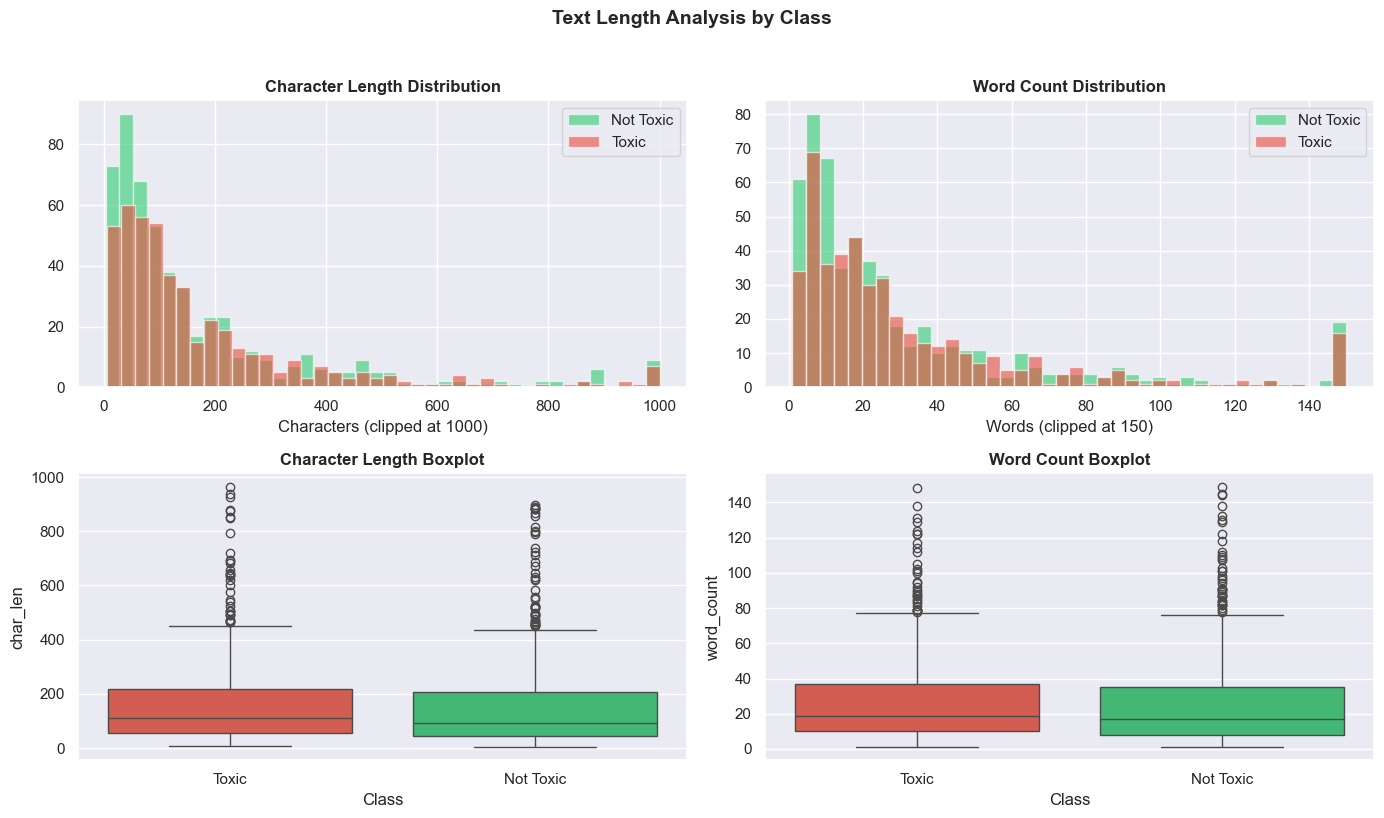

In [46]:
df['char_len'] = df['Text'].str.len()
df['word_count'] = df['Text'].str.split().str.len()

print('=== Overall Text Length Stats ===')
print(df[['char_len', 'word_count']].describe().round(1))
print('\n=== Median by Class ===')
print(df.groupby('IsToxic')[['char_len', 'word_count']].median())
print('\nKey insight: toxic comments are slightly longer than non-toxic ones')
print('Using median not mean — distribution is highly skewed by outliers')

# Visualización completa: histogramas + boxplots
df_plot = df.copy()
df_plot['Class'] = df_plot['IsToxic'].map({False: 'Not Toxic', True: 'Toxic'})

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Histograma de caracteres
for label, color in [(False, '#2ecc71'), (True, '#e74c3c')]:
    subset = df[df['IsToxic'] == label]['char_len']
    axes[0,0].hist(subset.clip(upper=1000), bins=40, alpha=0.6,
                   color=color, label='Not Toxic' if not label else 'Toxic')
axes[0,0].set_title('Character Length Distribution', fontweight='bold')
axes[0,0].set_xlabel('Characters (clipped at 1000)')
axes[0,0].legend()

# Histograma de palabras
for label, color in [(False, '#2ecc71'), (True, '#e74c3c')]:
    subset = df[df['IsToxic'] == label]['word_count']
    axes[0,1].hist(subset.clip(upper=150), bins=40, alpha=0.6,
                    color=color, label='Not Toxic' if not label else 'Toxic')
axes[0,1].set_title('Word Count Distribution', fontweight='bold')
axes[0,1].set_xlabel('Words (clipped at 150)')
axes[0,1].legend()

# Boxplot de caracteres
sns.boxplot(data=df_plot[df_plot['char_len'] < 1000], x='Class', y='char_len',
            palette={'Not Toxic': '#2ecc71', 'Toxic': '#e74c3c'}, ax=axes[1,0])
axes[1,0].set_title('Character Length Boxplot', fontweight='bold')

# Boxplot de palabras
sns.boxplot(data=df_plot[df_plot['word_count'] < 150], x='Class', y='word_count',
            palette={'Not Toxic': '#2ecc71', 'Toxic': '#e74c3c'}, ax=axes[1,1])
axes[1,1].set_title('Word Count Boxplot', fontweight='bold')

plt.suptitle('Text Length Analysis by Class', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

=== Pattern Frequency by Class ===
URLs                           | Toxic: 0.2% | Not Toxic: 2.0%
Mentions (@)                   | Toxic: 0.7% | Not Toxic: 0.4%
Uppercase blocks (>30%)        | Toxic: 3.1% | Not Toxic: 2.0%
Repeated chars (loool)         | Toxic: 21.7% | Not Toxic: 21.0%


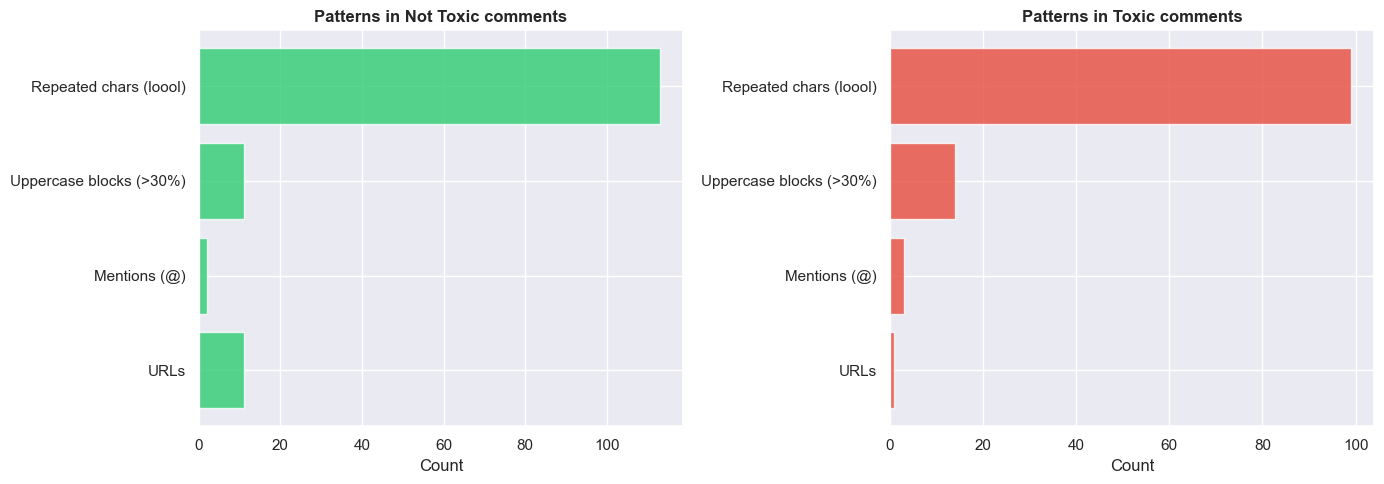

In [52]:
df['has_url']         = df['Text'].str.contains(r'https?://|www\.', regex=True)
df['has_mention']     = df['Text'].str.contains(r'@\w+', regex=True)
df['has_uppercase']   = df['Text'].apply(
    lambda x: sum(1 for c in x if c.isupper()) / max(len(x), 1) > 0.3
)

df['has_repeat_char'] = df['Text'].apply(
    lambda x: bool(re.search(r'(.)\1{2,}', str(x)))
)

patterns = ['has_url', 'has_mention', 'has_uppercase', 'has_repeat_char']
pattern_labels = ['URLs', 'Mentions (@)', 'Uppercase blocks (>30%)', 'Repeated chars (loool)']

print('=== Pattern Frequency by Class ===')
for pat, label in zip(patterns, pattern_labels):
    toxic_pct = df[df['IsToxic']==True][pat].mean() * 100
    clean_pct = df[df['IsToxic']==False][pat].mean() * 100
    print(f'{label:30s} | Toxic: {toxic_pct:.1f}% | Not Toxic: {clean_pct:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, label, pats in zip(
    axes,
    ['Not Toxic', 'Toxic'],
    [df[df['IsToxic']==False], df[df['IsToxic']==True]]
):
    counts = [pats[p].sum() for p in patterns]
    ax.barh(pattern_labels, counts,
            color='#2ecc71' if label == 'Not Toxic' else '#e74c3c', alpha=0.8)
    ax.set_title(f'Patterns in {label} comments', fontweight='bold')
    ax.set_xlabel('Count')

plt.tight_layout()
plt.show()

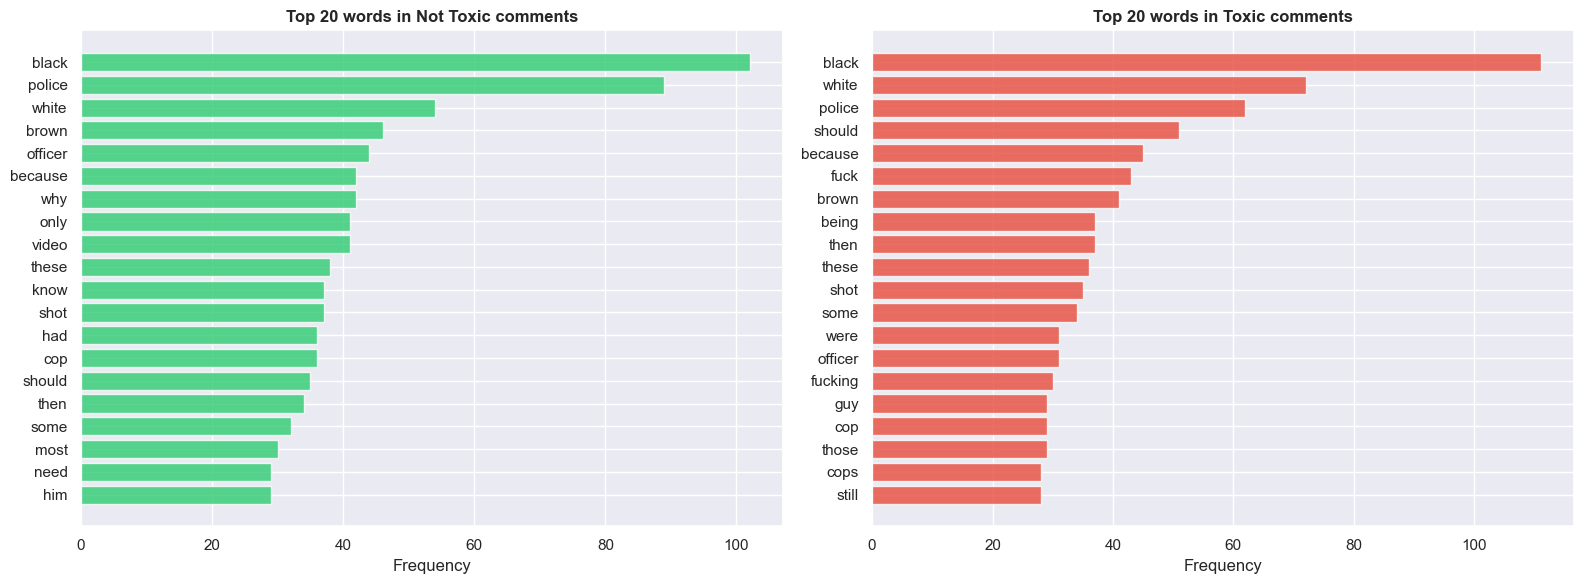

In [57]:

stopwords = {'the','a','an','is','it','in','of','to','and','that','this',
            'for','are','was','with','have','has','be','on','at','or',
            'but','not','they','he','she','we','you','i','his','her',
            'their','our','its','by','from','as','so','do','did','what',
            'how','if','will','can','about','people','just','like','get',
            'your','all','more','one','im','dont','its','been','would',
            'there','than','when','up','out','who','my','me','no','them'}

fig, axes = plt.subplots(1, 2, figsize=(16,6))

for ax, label, title, color in [
    (axes[0], False, 'Top 20 words in Not Toxic comments', '#2Ecc71'),
    (axes[1], True, 'Top 20 words in Toxic comments', '#e74c3c')
]:
    words = ''.join(df[df['IsToxic'] == label]['Text'].str.lower().tolist()).split()
    words = [w for w in words if w.isalpha() and w not in stopwords and len(w) > 2]
    top20 = Counter(words).most_common(20)
    words_list, counts = zip(*top20)

    ax.barh(words_list[::-1], counts[::-1], color=color, alpha=0.8)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Frequency')

plt.tight_layout()
plt.show()
    

In [ ]:
short = df[df['char_len'] < 10][['Text', 'IsToxic', 'char_len']]
print(f'texts with < 10 chars: {len(short)}')
print(short.to_string())
print('\nDecision: keep them all — even the very short ones can be toxic (e.g. "Go die")')

In [58]:
conclusions = {
    'Dataset size':         '997 rows after deduplication',
    'Class balance':        '54% not toxic / 46% toxic — balanced, no SMOTE needed',
    'Nulls':                'None — dataset is complete',
    'Duplicates removed':   '6 case-insensitive dupes removed to prevent data leakage',
    'Text length':          'Highly skewed — median 101 chars, max 4421 chars',
    'Toxic length':         'Toxic comments slightly shorter — insults are direct',
    'Patterns':             'Uppercase and repeated chars more frequent in toxic',
    'Columns dropped':      'CommentId, VideoId, all secondary labels (< 50 examples)',
    'Target variable':      'IsToxic — binary classification',
    'Validation strategy':  'StratifiedKFold k=5 — too few rows for single split',
    'Metric':               'F1 binary — more informative than accuracy',
    'class_weight':         'balanced — preventive measure for all models',
    'Augmentation':         'To consider — 997 rows causes structural overfitting',
    'Ambiguous words':      'black, white, police appear in both classes — context matters',
    'TF-IDF limitation':    'Bag-of-words misses context — supports BERT as next step',
}

print('=== EDA CONCLUSIONS ===')
for k, v in conclusions.items():
    print(f'  {k:25s} → {v}')

=== EDA CONCLUSIONS ===
  Dataset size              → 997 rows after deduplication
  Class balance             → 54% not toxic / 46% toxic — balanced, no SMOTE needed
  Nulls                     → None — dataset is complete
  Duplicates removed        → 6 case-insensitive dupes removed to prevent data leakage
  Text length               → Highly skewed — median 101 chars, max 4421 chars
  Toxic length              → Toxic comments slightly shorter — insults are direct
  Patterns                  → Uppercase and repeated chars more frequent in toxic
  Columns dropped           → CommentId, VideoId, all secondary labels (< 50 examples)
  Target variable           → IsToxic — binary classification
  Validation strategy       → StratifiedKFold k=5 — too few rows for single split
  Metric                    → F1 binary — more informative than accuracy
  class_weight              → balanced — preventive measure for all models
  Augmentation              → To consider — 997 rows causes struct

In [60]:
df_clean = df[['Text', 'IsToxic']].copy()
df_clean.to_csv('../../data/processed/youtoxic_clean.csv', index=False)

print(f'   Saved: data/processed/youtoxic_clean.csv')
print(f'   Shape: {df_clean.shape}')
print(f'   Columns: {df_clean.columns.tolist()}')
print(f'   Class distribution:')
print(df_clean['IsToxic'].value_counts())

   Saved: data/processed/youtoxic_clean.csv
   Shape: (995, 2)
   Columns: ['Text', 'IsToxic']
   Class distribution:
IsToxic
False    538
True     457
Name: count, dtype: int64
